# RTN 取整基线 与 LLM.int8() 混合精度分解

> **PTQ 教学 demo 系列 · 01 / 13**
> 配套博客：[《RTN 基线与 LLM.int8()：大模型量化的 outlier 问题》](https://lrypcy.github.io/2026/08/24/ptq-01-rtn-llmint8/)（PTQ 深度系列 · 第 1 篇）

**一段话原理**：RTN（Round-to-Nearest）是最朴素的训练后量化——把浮点值除以 scale $s$ 后四舍五入到最近格点，$\hat{x}=s\cdot\mathrm{round}(x/s)$，逐元素误差上界 $s/2$ 完全由动态范围决定。LLM 激活中存在少数固定复现的 **outlier 特征列**（论文观察：约 0.1% 的通道贡献约 30% 的激活范数），把全局 scale 撑大一个数量级，正常值的有效位宽从 8 bit 坍塌到约 4 bit——这是 INT8 推理在 6.7B+ 规模模型上崩溃的根因。**LLM.int8()**（arXiv:2208.07339）的解法是混合精度分解：按幅度阈值 $\alpha=6.0$ 把 outlier 列整体拆出走 FP16 精确路径，其余干净列走标准 INT8 GEMM（token-wise × channel-wise scale，外积反量化），两路相加严格还原 $XW$。

本 demo 在 toy 规模合成数据（128×256 激活 × 256×256 权重，SEED 固定，纯 numpy，秒级跑完）上依次演示：① MinMax 对称/非对称量化的 round-trip 与误差来源；② 带 outlier 列的合成激活；③ 全 INT8 per-tensor RTN 的崩溃机制；④ 阈值拆列的双路径 GEMM；⑤ 全 INT8 vs 混合分解的相对误差对比。

## 第 1 步 · 环境与量化工具箱

这步在做什么：导入依赖并固定随机种子，实现贯穿全篇的两个 MinMax 量化器——**对称 absmax** 与**非对称仿射（带零点）**——以及统一的相对 Frobenius 误差指标，后面每一步都建立在这几个函数之上。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0        # 全局随机种子: 保证每次运行结果完全可复现
QMAX = 127      # int8 对称量化正电平上限: 格点范围 [-127, 127]


def quantize_symmetric(x, axis=None):
    """对称 MinMax(absmax) 量化: s = max|x| / 127, q = round(x / s).

    axis=None 为 per-tensor(单一全局 scale);
    axis=1    为 per-row/token-wise(scale 形状 (T, 1));
    axis=0    为 per-column/channel-wise(scale 形状 (1, K)).
    """
    if axis is None:
        amax = np.abs(x).max()
    else:
        amax = np.abs(x).max(axis=axis, keepdims=True)
    s = np.where(amax > 0, amax / QMAX, np.float32(1.0)).astype(np.float32)
    q = np.clip(np.round(x / s), -QMAX, QMAX).astype(np.int8)
    return q, s


def quantize_affine(x):
    """非对称 MinMax 仿射量化: 把实际范围 [xmin, xmax] 映射到 [-127, 127].

    引入零点 zp, 适合单侧/偏斜分布; 反量化 x_hat = s * (q - zp).
    """
    xmin, xmax = x.min(), x.max()
    s = ((xmax - xmin) / (2 * QMAX)).astype(np.float32)
    s = np.float32(max(float(s), 1e-12))
    zp = np.clip(np.round(-xmin / s) - QMAX, -QMAX, QMAX).astype(np.float32)
    q = np.clip(np.round(x / s + zp), -QMAX, QMAX).astype(np.int8)
    return q, s, zp


def rel_err(y_hat, y):
    """相对 Frobenius 误差 ||y_hat - y||_F / ||y||_F."""
    return float(np.linalg.norm(y_hat - y) / np.linalg.norm(y))


print("工具箱就绪: SEED=%d, QMAX=%d" % (SEED, QMAX))

工具箱就绪: SEED=0, QMAX=127


## 第 2 步 · MinMax 量化的 round-trip：误差从哪来

这步在做什么：在两组分布（零均值高斯 vs 单侧偏斜）上做「量化 → 反量化」round-trip，验证两件事——对称量化对规整分布已经足够好；一旦分布偏斜（动态范围不跨零），对称 scale 要覆盖从未用到的负半轴，等效浪费一半电平，非对称零点量化明显更优。这也点明了 RTN 误差的全部来源：**舍入噪声方差 ≈ $s^2/12$，一切由 scale 决定**——为后面「scale 被 outlier 绑架」的崩溃埋下伏笔。

In [2]:
np.random.seed(SEED)

gauss = np.random.randn(512, 512).astype(np.float32)                 # 分布 A: 零均值、左右对称
skew = np.random.lognormal(0.0, 1.0, (512, 512)).astype(np.float32)  # 分布 B: 恒正、重尾偏斜

print("%-18s%-14s%-16s" % ("数据分布", "对称 absmax", "非对称 affine"))
print("-" * 48)
for name, z in [("高斯 N(0, 1)", gauss), ("偏斜 lognormal", skew)]:
    q_s, s_s = quantize_symmetric(z)                      # 对称: 只有一个 scale
    rec_s = q_s.astype(np.float32) * s_s
    q_a, s_a, zp_a = quantize_affine(z)                   # 非对称: scale + 零点
    rec_a = s_a * (q_a.astype(np.float32) - zp_a)
    print("%-20s%-14.5f%-16.5f" % (name, rel_err(rec_s, z), rel_err(rec_a, z)))

print()
print("对称量化在偏斜数据上的 scale 被最大值劫持, 且要覆盖空置的负半轴;")
print("非对称量化用零点平移把 254 个电平全部用在真实范围上, 误差明显更低.")

数据分布              对称 absmax     非对称 affine      
------------------------------------------------
高斯 N(0, 1)          0.01104       0.01040         
偏斜 lognormal        0.07500       0.03670         

对称量化在偏斜数据上的 scale 被最大值劫持, 且要覆盖空置的负半轴;
非对称量化用零点平移把 254 个电平全部用在真实范围上, 误差明显更低.


## 第 3 步 · 合成带 outlier 列的激活数据

这步在做什么：构造 toy 规模的激活 $X\in\mathbb{R}^{128\times 256}$ 与权重 $W\in\mathbb{R}^{256\times 256}$，向固定的 6 个特征列注入幅值 25～45 的超大激活（只在约 75% 的 token 上出现）——刻意复刻 LLM.int8() 论文的核心观察：**极少数固定通道携带不成比例的范数**。这是后续所有对比的数据基础：若不含这种超大异常列，LLM.int8() 相对朴素 INT8 的增益根本显不出来。

In [3]:
T, K, N_OUT = 128, 256, 256        # token 数 / 输入特征维 / 输出通道维(均 <= 512)


def build_synthetic(tokens=T, d_in=K, d_out=N_OUT, n_out=6,
                    amp=(25.0, 45.0), active_prob=0.75):
    """合成激活 X (tokens x d_in) 与权重 W (d_in x d_out).

    - 正常维度 ~ N(0, 0.75^2): 幅度约 +-3.5 (对齐论文观察)
    - n_out 条持久异常列: 幅值 25~45, 仅约 active_prob 的 token 上激活
    - 函数开头重置随机种子, 保证与本目录 run.py / results.json 的数字一致
    """
    np.random.seed(SEED)
    X = np.random.randn(tokens, d_in).astype(np.float32) * 0.75
    W = (np.random.randn(d_in, d_out) * 0.08).astype(np.float32)
    out_cols = np.linspace(5, d_in - 5, n_out).astype(int)
    for j in out_cols:
        active = np.random.rand(tokens) < active_prob          # 跨 token 稳定但非全时出现
        sign = np.random.choice([-1.0, 1.0], tokens)           # 论文: outlier 通常单侧
        X[active, j] = sign[active] * np.random.uniform(*amp, active.sum())
    return X, W, out_cols


X, W, OUT_COLS = build_synthetic()
X_clean = X.copy()
X_clean[:, OUT_COLS] = 0.0                                     # 剥离异常列后的"正常部分"

mag_ratio = float(np.abs(X[:, OUT_COLS]).max() / np.abs(X_clean).max())
norm_frac = float(np.abs(X[:, OUT_COLS]).sum() / np.abs(X).sum())
print("激活 X: %s   权重 W: %s" % (X.shape, W.shape))
print("注入异常列: %s  (%.1f%% of %d 维)" % (OUT_COLS.tolist(), len(OUT_COLS) / K * 100, K))
print("正常维度范围: [%.2f, %.2f]   (论文观察: 约 [-3.5, 3.5])" % (X_clean.min(), X_clean.max()))
print("异常幅值约为正常的 %.1fx" % mag_ratio)
print("异常列范数占比: %.1f%%  (%d/%d 列)" % (norm_frac * 100, len(OUT_COLS), K))

激活 X: (128, 256)   权重 W: (256, 256)
注入异常列: [5, 54, 103, 152, 201, 251]  (2.3% of 256 维)
正常维度范围: [-3.49, 2.87]   (论文观察: 约 [-3.5, 3.5])
异常幅值约为正常的 12.9x
异常列范数占比: 51.3%  (6/256 列)


## 第 4 步 · 可视化：异常列长什么样

这步在做什么：逐列画最大幅值（log 轴），直观看到 6 个异常列把全局最大幅值抬到正常值的十几倍、远超阈值 $\alpha=6.0$；右图是逐 token 行最大值的分布——异常列几乎污染了每一个 token，这正是后面「token-wise 粒度也救不了」的直接原因。

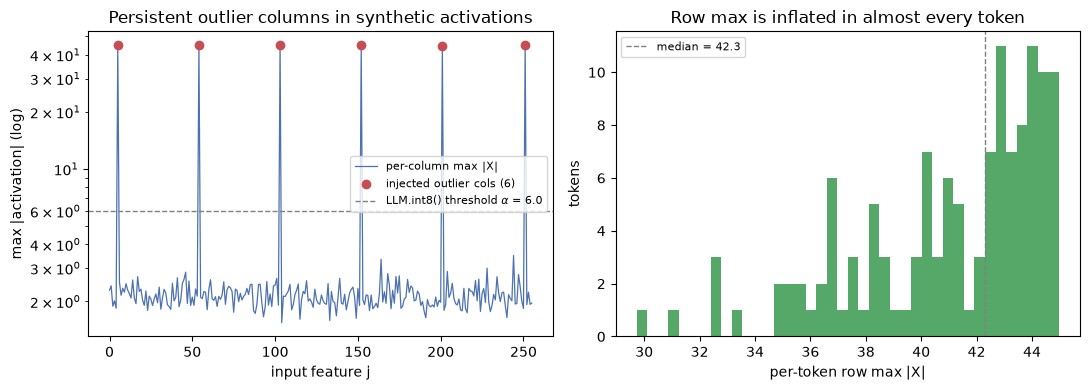

In [4]:
col_max = np.abs(X).max(axis=0)
row_max = np.abs(X).max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(np.arange(K), col_max, lw=0.9, color="#4C72B0", label="per-column max |X|")
axes[0].scatter(OUT_COLS, col_max[OUT_COLS], color="#C44E52", zorder=5,
                label="injected outlier cols (%d)" % len(OUT_COLS))
axes[0].axhline(6.0, color="gray", ls="--", lw=1, label="LLM.int8() threshold $\\alpha$ = 6.0")
axes[0].set_xlabel("input feature j")
axes[0].set_ylabel("max |activation| (log)")
axes[0].set_title("Persistent outlier columns in synthetic activations")
axes[0].legend(fontsize=8)

axes[1].hist(row_max, bins=40, color="#55A868")
axes[1].axvline(float(np.median(row_max)), color="gray", ls="--", lw=1,
                label="median = %.1f" % np.median(row_max))
axes[1].set_xlabel("per-token row max |X|")
axes[1].set_ylabel("tokens")
axes[1].set_title("Row max is inflated in almost every token")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 第 5 步 · 全 INT8 基线：双张量 per-tensor RTN 及其崩溃机制

这步在做什么：用**单一全局 scale** 分别量化 $X$ 和 $W$ 再做矩阵乘，复现朴素 INT8 的失败；随后用三个数字解剖崩溃链条——scale 被异常值绑架（$s_x$ 由幅值 45 决定）→ 正常值等效位宽坍塌（只剩十几个电平）→ 大量元素幅度不足半步被直接量化到 0（信息湮灭）。

In [5]:
Y_ref = X @ W                                        # FP32 参考输出

xq_t, sx_t = quantize_symmetric(X)                   # 各自只有一个全局 scale
wq_t, sw_t = quantize_symmetric(W)
Y_rtn = (xq_t.astype(np.float32) * sx_t) @ (wq_t.astype(np.float32) * sw_t)

s_x = float(sx_t)
levels = 2 * int(3.5 / s_x)                          # 正常值域 [-3.5, 3.5] 能占用的电平数
frac_zero = float(np.mean(np.abs(X) < s_x / 2))      # 幅度 < s_x/2 -> round 到 0
Y_normal_true = X_clean @ W                          # 正常部分的理想输出

print("per-tensor scale s_x = %.4f  (由异常列最大幅值 %.1f 决定)" % (s_x, np.abs(X).max()))
print("正常值域 [-3.5, 3.5] 只分到约 %d 个电平 -> 等效精度 %.1f bit (名义 8 bit)"
      % (levels, np.log2(levels)))
print("幅度 < s_x/2 被直接量化为 0 的元素占比: %.1f%%" % (frac_zero * 100))
print()
print("双张量 per-tensor RTN           整体相对误差 = %.5f" % rel_err(Y_rtn, Y_ref))
print("其中对正常部分输出的破坏高达 %.3f  <- 信息载体被异常值淹没"
      % rel_err(Y_rtn, Y_normal_true))

per-tensor scale s_x = 0.3541  (由异常列最大幅值 45.0 决定)
正常值域 [-3.5, 3.5] 只分到约 18 个电平 -> 等效精度 4.2 bit (名义 8 bit)
幅度 < s_x/2 被直接量化为 0 的元素占比: 18.7%

双张量 per-tensor RTN           整体相对误差 = 0.02400
其中对正常部分输出的破坏高达 6.375  <- 信息载体被异常值淹没


## 第 6 步 · 对照组：token-wise 动态量化，但不拆异常列

这步在做什么：把粒度做到 vector-wise——激活每行（token）一个动态 scale、权重每列（输出通道）一个 scale——但**不做异常列分离**。由于异常列在几乎所有 token 上都出现，每一行的 $\max|x|$ 照样被撑到 40 上下，误差纹丝不动。这一步证明：**提高 scale 粒度不是解药，物理分离 outlier 才是**。

In [6]:
xq_r, sx_r = quantize_symmetric(X, axis=1)           # 每 token 一个 scale, 形状 (T, 1)
wq_c, sw_c = quantize_symmetric(W, axis=0)           # 每输出通道一个 scale, 形状 (1, N)
Y_tok = (xq_r.astype(np.float32) * sx_r) @ (wq_c.astype(np.float32) * sw_c)

print("逐 token 行 max|x| 的中位数 = %.1f, 远大于正常值域 3.5 -> 行 scale 仍被异常列绑架"
      % np.median(row_max))
print("token-wise 动态量化(不拆列)     相对误差 = %.5f   <- 与 per-tensor 几乎一样差"
      % rel_err(Y_tok, Y_ref))

逐 token 行 max|x| 的中位数 = 42.3, 远大于正常值域 3.5 -> 行 scale 仍被异常列绑架
token-wise 动态量化(不拆列)     相对误差 = 0.02062   <- 与 per-tensor 几乎一样差


## 第 7 步 · 方法核心：LLM.int8() 混合精度分解

这步在做什么：按幅度阈值 $\alpha=6.0$ 检出异常列集合 $O=\{\,j:\max_i|x_{ij}|>\alpha\,\}$，做**精确加性分解**（两路支撑集互斥、交叉项为零，因此分解本身零近似）：

$$Y=XW=\underbrace{X_{\text{int8}}W_{\text{int8}}}_{\text{INT8 主路径}}+\underbrace{X_{\text{outlier}}W_{\text{outlier}}}_{\text{FP16 兜底小 GEMM}}$$

主路径用 **int32 整数累加** 完成 GEMM（Tensor Core int8 指令的形态），反量化被吸收进 scale 外积 $Y_{\text{int8}}=C_q\odot(s_X\otimes s_W)$，成本 $O(T+N)$ 而非 $O(TN)$；注意权重必须沿收缩维 $K$ 与激活的异常列**同步按行切分**，否则两路对不上。

In [7]:
def llm_int8_matmul(x, w, alpha=6.0):
    r"""简化版 LLM.int8() (arXiv:2208.07339).

    Step 1  异常列判定: O = { j | max_t |x[t,j]| > alpha }
    Step 2  精确分解: 激活按列切, 权重沿收缩维按行同步切
            x = x_int8 + x_outlier,  w = w_int8 + w_outlier
    Step 3  INT8 路径 vector-wise 量化: 激活 token-wise scale (T,1),
            权重 channel-wise scale (1,N); int32 整数累加 GEMM
    Step 4  外积反量化: Y_int8 = C_q * outer(sx, sw), 成本 O(T+N)
    Step 5  FP16 兜底路径: Y_fp = x[:,O] @ w[O,:] (精确, 不量化)
    返回 (Y, O): 混合精度输出与检出的异常列索引.
    """
    col_max = np.abs(x).max(axis=0)                            # Step 1
    o_cols = np.where(col_max > alpha)[0]

    x_l = x.copy(); x_l[:, o_cols] = 0.0                       # Step 2
    w_l = w.copy(); w_l[o_cols, :] = 0.0

    sx = np.abs(x_l).max(axis=1, keepdims=True) / QMAX         # Step 3, (T, 1)
    sw = np.abs(w_l).max(axis=0, keepdims=True) / QMAX         #        (1, N)
    sx = np.where(sx > 0, sx, np.float32(1e-9))                # 防除零
    sw = np.where(sw > 0, sw, np.float32(1e-9))
    xq = np.clip(np.round(x_l / sx), -QMAX, QMAX).astype(np.int8)
    wq = np.clip(np.round(w_l / sw), -QMAX, QMAX).astype(np.int8)

    c_int = xq.astype(np.int32) @ wq.astype(np.int32)          # 整数累加 GEMM
    y_int8 = c_int.astype(np.float32) * (sx * sw)              # Step 4, (T,1)*(1,N) 广播
    y_fp = x[:, o_cols].astype(np.float32) @ w[o_cols, :].astype(np.float32)   # Step 5
    return y_int8 + y_fp, o_cols


Y_llm, detected = llm_int8_matmul(X, W, alpha=6.0)
print("阈值 alpha=6.0 检出异常列: %s" % detected.tolist())
print("注入的异常列:             %s   <- 判定完全命中" % OUT_COLS.tolist())
print("LLM.int8() 混合精度             相对误差 = %.5f" % rel_err(Y_llm, Y_ref))

阈值 alpha=6.0 检出异常列: [5, 54, 103, 152, 201, 251]
注入的异常列:             [5, 54, 103, 152, 201, 251]   <- 判定完全命中
LLM.int8() 混合精度             相对误差 = 0.00154


## 第 8 步 · 汇总对比：误差阶梯与内存账

这步在做什么：把四种方案放到同一坐标系（左图：相对误差，log 轴；右图：权重持久化内存），并核对内存账——异常行只有 $|O|=6$ 行，FP16 副本的字节开销可以忽略，INT8 主体的压缩率几乎无损。

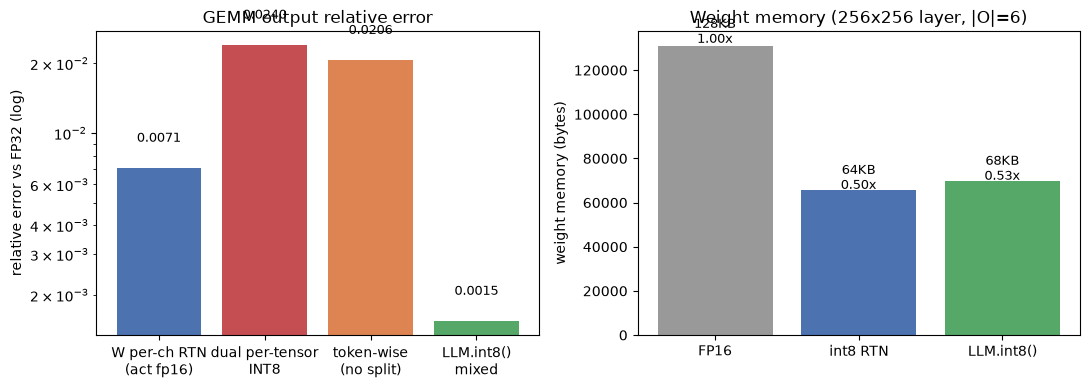

方案                                相对误差        权重内存
----------------------------------------------------------
(1) 权重 per-channel RTN(激活 FP16)     0.00706     -
(2) 双张量 per-tensor INT8             0.02400     65540 B (2.00x)
(3) token-wise 动态(不拆列)              0.02062     -
(4) LLM.int8() 混合精度                 0.00154     69632 B (1.88x)
(2)/(4) 误差比: 15.6 倍


In [8]:
Y_wonly = X @ (wq_c.astype(np.float32) * sw_c)       # 方案(1): 只量化权重, 激活保持 FP16

errs = [rel_err(Y_wonly, Y_ref), rel_err(Y_rtn, Y_ref),
        rel_err(Y_tok, Y_ref), rel_err(Y_llm, Y_ref)]
names = ["W per-ch RTN\n(act fp16)", "dual per-tensor\nINT8",
         "token-wise\n(no split)", "LLM.int8()\nmixed"]

m_fp16 = 2 * K * N_OUT                                    # FP16 基线
m_rtn = K * N_OUT + 4                                     # INT8 主体 + 1 个 per-tensor scale(fp32)
m_llm = K * N_OUT + 4 * N_OUT + 2 * len(detected) * N_OUT # + 逐列 scale + 异常行 FP16 副本

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bars = axes[0].bar(names, errs, color=["#4C72B0", "#C44E52", "#DD8452", "#55A868"])
axes[0].set_yscale("log")
axes[0].set_ylabel("relative error vs FP32 (log)")
axes[0].set_title("GEMM output relative error")
for b, e in zip(bars, errs):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() * 1.3,
                 "%.4f" % e, ha="center", fontsize=9)

mems = [("FP16", m_fp16), ("int8 RTN", m_rtn), ("LLM.int8()", m_llm)]
axes[1].bar([n for n, _ in mems], [v for _, v in mems],
            color=["#999999", "#4C72B0", "#55A868"])
axes[1].set_ylabel("weight memory (bytes)")
axes[1].set_title("Weight memory (%dx%d layer, |O|=%d)" % (K, N_OUT, len(detected)))
for i, (_, v) in enumerate(mems):
    axes[1].text(i, v * 1.01, "%dKB\n%.2fx" % (v // 1024, v / m_fp16),
                 ha="center", fontsize=9)

fig.tight_layout()
plt.show()

print("%-34s%-12s%s" % ("方案", "相对误差", "权重内存"))
print("-" * 58)
print("%-36s%-12.5f%s" % ("(1) 权重 per-channel RTN(激活 FP16)", errs[0], "-"))
print("%-36s%-12.5f%d B (%.2fx)" % ("(2) 双张量 per-tensor INT8", errs[1], m_rtn, m_fp16 / m_rtn))
print("%-36s%-12.5f%s" % ("(3) token-wise 动态(不拆列)", errs[2], "-"))
print("%-36s%-12.5f%d B (%.2fx)" % ("(4) LLM.int8() 混合精度", errs[3], m_llm, m_fp16 / m_llm))
print("(2)/(4) 误差比: %.1f 倍" % (errs[1] / errs[3]))

## 结果解读

**合成数据成功复刻了论文观察的异常形态**：6/256 ≈ 2.3% 的异常列携带了 51.3% 的激活总范数，幅值达正常值的 12.9 倍；阈值 $\alpha=6.0$ 的自动检出与注入位置逐一吻合（`[5, 54, 103, 152, 201, 251]`）。

**崩溃机制被三个数字精确刻画**（第 5 步）：per-tensor scale $s_x=0.3541$ 完全由异常列的最大幅值 45.0 决定；正常值域 $[-3.5, 3.5]$ 只分到 18 个电平，等效精度从 8 bit 坍塌到 **4.2 bit**；**18.7%** 的元素因幅度不足半个 step 被直接量化为 0。宏观后果：双张量 per-tensor INT8 整体相对误差 **2.40%**，而对真正承载信息的「正常部分输出」，破坏高达约 6.4 倍——信息湮灭。

**四条方案的误差阶梯**（上方汇总表 / 左图）：

| 方案 | 相对误差 | 一句话诊断 |
|---|---|---|
| 权重 per-channel RTN（激活 FP16） | 0.706% | 权重分布规整，RTN 本身没问题 |
| 双张量 per-tensor INT8 | 2.400% | scale 被 outlier 绑架 |
| token-wise 动态（不拆列） | 2.062% | 粒度细化救不了被绑架的每一行 |
| **LLM.int8() 混合精度** | **0.154%** | 物理分离 outlier，INT8 主干恢复满精度 |

LLM.int8() 把误差拉回与「仅权重量化」同一量级，比朴素 INT8 好约 **15 倍**；内存账同样成立：131072 B（FP16）→ 65540 B（INT8，压缩 2.00x）→ 69632 B（LLM.int8()，仍压缩 1.88x）——因为 $|O|=6$ 行的 FP16 副本只占 3072 字节。

## 方法局限

1. **阈值脆弱**：$\alpha=6.0$ 是经验值，随模型族、位宽、层深漂移；设小了 outlier 泄漏进 INT8 路径，设大了 FP16 路径膨胀。
2. **部署显存不减反增**：真实实现必须保留完整 FP16 权重副本随时喂给兜底路径，实际显存约 2×FP16——本 demo 的内存账只计了 GEMM 输入侧，未含这份副本。
3. **FP16 路径拖延迟**：论文报告 175B 上约 0.1% 的列消耗约 20% 的 GEMM 时间（fp16 单元吞吐远低于 int8 Tensor Core，且双路径需同步点），端到端延迟基本无收益。
4. **toy 数据只复现形态、不复现后果**：真实模型的量化误差经残差流与注意力逐层累积放大，表现为 ppl 爆炸；单层 GEMM 的相对误差无法直接外推到端到端困惑度。

**系列衔接**：LLM.int8() 切断的是「scale 被绑架」这第一个环节；后续方法从另外两端入手——SmoothQuant 用迁移 scale 从数学上消灭 outlier（博客第 6 篇），GPTQ 用 Hessian 二阶补偿直接修正权重误差（博客第 2 篇）。